In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/kaggle/input/datasets/rasiqgulzar18/multiple-lr/house_prices_dataset.csv')

In [3]:
df.shape

(25000, 3)

In [4]:
df.head(50)

,square_feet,num_rooms,price
0,1360,9,582053
1,4272,7,1449501
2,3592,2,1103204
3,966,1,272878
4,4926,8,1652121
5,3944,9,1473116
6,3671,5,1240690
7,3419,6,1107803
8,630,2,211398
9,2185,5,731635


In [5]:
x=df.iloc[:,[0,1]].values
x

array([[1360,    9],
       [4272,    7],
       [3592,    2],
       ...,
       [4786,    4],
       [4507,    4],
       [2031,    8]])

In [6]:
y=df.iloc[:,[2]].values
y

array([[ 582053],
       [1449501],
       [1103204],
       ...,
       [1455905],
       [1458421],
       [ 809744]])

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [8]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [9]:
model.fit(x_train,y_train)

LinearRegression()

In [10]:
a=model.score(x_test,y_test)
a*100

98.37690045870171

In [11]:
test=model.predict([[2000,7]])
test

array([[740388.42651013]])

In [12]:
model.coef_

array([[  299.67941793, 20038.34555394]])

In [13]:
model.intercept_

array([761.17176582])

In [14]:
#m1.x1+m2.x2+c
result=299.76109492*2000+20039.34662774*7+808.30261267
result

740605.91884685

In [15]:
import pickle
with open('multiple_lr.pkl','wb') as f:
    pickle.dump(model,f)

Feature Matrix Shape: (50, 4)
Features: [SquareFeet, Rooms, AgeOfHouse(yrs), DistanceToCenter(km)]
[[1360    9   39   21]
 [4272    7   29    2]
 [3592    2   15   20]
 [ 966    1   43   28]
 [4926    8    8   15]]

Coefficients:
  SquareFeet: 302.42
  Rooms: 22365.13
  AgeOfHouse: 155.75
  DistanceToCenter: 951.34
  Intercept: -44680.85


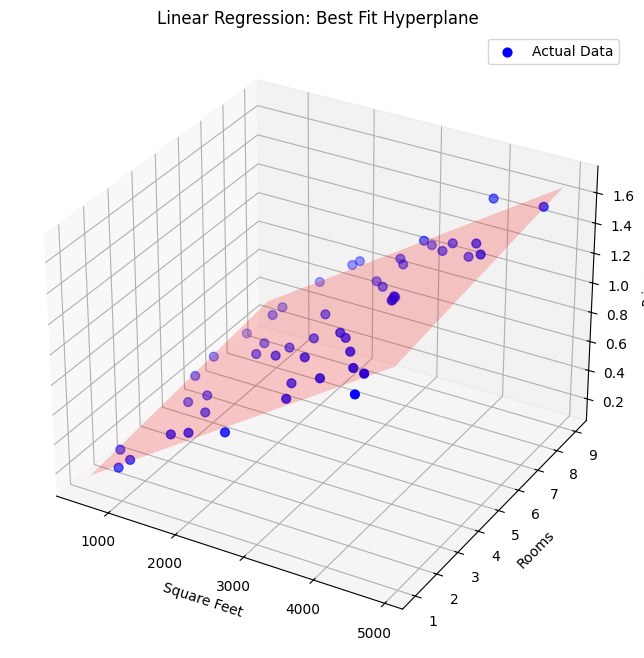

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Setup Data & Model
# Original features: [SquareFeet, Rooms, Price]
data = np.array([[1360,9,582053],[4272,7,1449501],[3592,2,1103204],[966,1,272878],[4926,8,1652121],[3944,9,1473116],[3671,5,1240690],[3419,6,1107803],[630,2,211398],[2185,5,731635],[1269,4,409118],[2891,8,1057292],[2933,8,1023597],[1684,5,621088],[3885,8,1194758],[4617,6,1539601],[3404,6,1111599],[974,4,321937],[1582,3,467716],[3058,9,1051407],[2547,5,842706],[3247,4,1098535],[1475,6,540314],[2306,4,820936],[689,6,341307],[3234,8,1221166],[3505,8,1186453],[2399,6,860386],[1767,1,612540],[2028,1,659917],[3702,3,1162085],[4056,2,1232420],[4390,1,1239816],[1146,1,351822],[3388,6,1090278],[2935,7,993412],[1100,8,492583],[2863,3,840845],[2561,1,738659],[741,5,341667],[2541,8,859049],[3324,4,1074939],[3112,2,903516],[1863,9,765216],[1978,9,806254],[3056,3,1038545],[1275,7,584759],[4514,1,1387907],[534,8,232115],[3652,8,1255704]])

np.random.seed(42)
n_samples = len(data)

# New Feature 1: Age of House (years) — older houses slightly lower price
age_of_house = np.random.randint(1, 51, size=n_samples).reshape(-1, 1)

# New Feature 2: Distance to City Center (km) — farther = lower price
distance_to_center = np.random.randint(1, 31, size=n_samples).reshape(-1, 1)

# Original X (SquareFeet, Rooms) and y (Price)
X_original = data[:, :2]
y = data[:, 2]

# Extended X with 4 features: [SquareFeet, Rooms, AgeOfHouse, DistanceToCenter]
X = np.hstack([X_original, age_of_house, distance_to_center])

print("Feature Matrix Shape:", X.shape)  # (50, 4)
print("Features: [SquareFeet, Rooms, AgeOfHouse(yrs), DistanceToCenter(km)]")
print(X[:5])

model = LinearRegression().fit(X, y)

print("\nCoefficients:")
feature_names = ['SquareFeet', 'Rooms', 'AgeOfHouse', 'DistanceToCenter']
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name}: {coef:.2f}")
print(f"  Intercept: {model.intercept_:.2f}")

# 2. Create a Meshgrid for the Plane
# For visualization, we use SquareFeet & Rooms (first 2 features)
# and fix the new features at their mean values for the surface
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
xx, yy = np.meshgrid(x_range, y_range)

# 3. Predict Prices across the entire Grid
# Fix AgeOfHouse and DistanceToCenter at their mean for the surface plot
mean_age = X[:, 2].mean()
mean_dist = X[:, 3].mean()

flat_grid = np.c_[
    xx.ravel(),
    yy.ravel(),
    np.full(xx.ravel().shape, mean_age),
    np.full(xx.ravel().shape, mean_dist)
]
zz = model.predict(flat_grid).reshape(xx.shape)

# 4. Plotting (unchanged)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the Plane (The Hyperplane)
ax.plot_surface(xx, yy, zz, color='red', alpha=0.2, shade=False)

# Plot Actual Data Points
ax.scatter(X[:, 0], X[:, 1], y, color='blue', s=40, label='Actual Data')

ax.set_xlabel('Square Feet')
ax.set_ylabel('Rooms')
ax.set_zlabel('Price')
plt.title("Linear Regression: Best Fit Hyperplane")
plt.legend()
plt.show()